# STEP-1: Importing the necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# STEP-2: Exploratory Data Analysis

In [2]:
df = pd.read_csv("C:\\Users\\Yutika\\Desktop\\ETE Projects\\HousePrice\\MagicBricks.csv")
df.head(10)

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0
5,1300.0,4,3.0,Semi-Furnished,Rohini Sector 24,1.0,15500000,Ready_to_move,New_Property,Builder_Floor,6667.0
6,1350.0,4,3.0,Semi-Furnished,Rohini Sector 24,1.0,10000000,Ready_to_move,Resale,Builder_Floor,6667.0
7,650.0,2,2.0,Semi-Furnished,"Delhi Homes, Rohini Sector 24",1.0,4000000,Ready_to_move,New_Property,Apartment,6154.0
8,985.0,3,3.0,Unfurnished,Rohini Sector 21,1.0,6800000,Almost_ready,New_Property,Builder_Floor,6154.0
9,1300.0,4,4.0,Semi-Furnished,Rohini Sector 22,1.0,15000000,Ready_to_move,New_Property,Builder_Floor,6154.0


### 1) The number of missing values:
* ### Method-1

In [3]:
print(df.isnull().sum())    

Area             0
BHK              0
Bathroom         2
Furnishing       5
Locality         0
Parking         33
Price            0
Status           0
Transaction      0
Type             5
Per_Sqft       241
dtype: int64


* ### Method-2

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         1259 non-null   float64
 1   BHK          1259 non-null   int64  
 2   Bathroom     1257 non-null   float64
 3   Furnishing   1254 non-null   object 
 4   Locality     1259 non-null   object 
 5   Parking      1226 non-null   float64
 6   Price        1259 non-null   int64  
 7   Status       1259 non-null   object 
 8   Transaction  1259 non-null   object 
 9   Type         1254 non-null   object 
 10  Per_Sqft     1018 non-null   float64
dtypes: float64(4), int64(2), object(5)
memory usage: 108.3+ KB


* ### Method-3

Text(50.0, 0.5, 'No. of missing values per feature ')

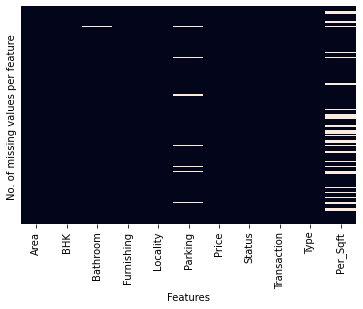

In [5]:
sns.heatmap(df.isnull(),cbar=False,yticklabels=False)
plt.xlabel("Features")
plt.ylabel("No. of missing values per feature ")

### 2) Other basic information 

In [6]:
# name of columns
df.columns

Index(['Area', 'BHK', 'Bathroom', 'Furnishing', 'Locality', 'Parking', 'Price',
       'Status', 'Transaction', 'Type', 'Per_Sqft'],
      dtype='object')

In [7]:
#shape of the dataset
df.shape

(1259, 11)

In [8]:
#descriptive stats (5 number summary)
df.describe()

,Area,BHK,Bathroom,Parking,Price,Per_Sqft
count,1259.000000,1259.000000,1257.000000,1226.000000,1.259000e+03,1018.000000
mean,1466.452724,2.796664,2.556086,1.935563,2.130670e+07,15690.136542
std,1568.055040,0.954425,1.042220,6.279212,2.560115e+07,21134.738568
min,28.000000,1.000000,1.000000,1.000000,1.000000e+06,1259.000000
25%,800.000000,2.000000,2.000000,1.000000,5.700000e+06,6364.000000
50%,1200.000000,3.000000,2.000000,1.000000,1.420000e+07,11291.500000
75%,1700.000000,3.000000,3.000000,2.000000,2.550000e+07,18000.000000
max,24300.000000,10.000000,7.000000,114.000000,2.400000e+08,183333.000000


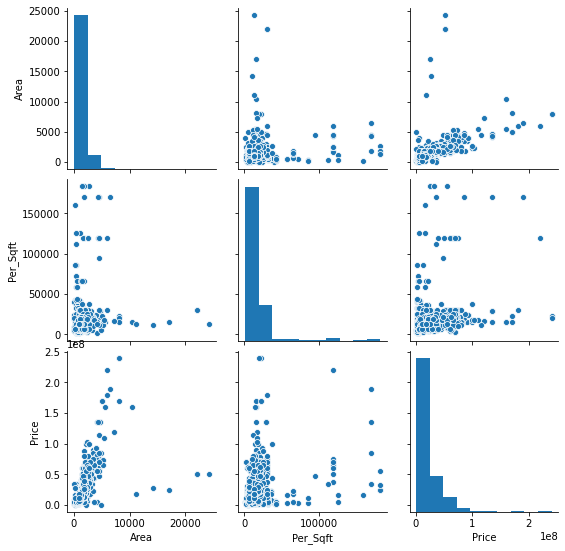

In [9]:
sns.pairplot(df[["Area","Per_Sqft","Price"]])

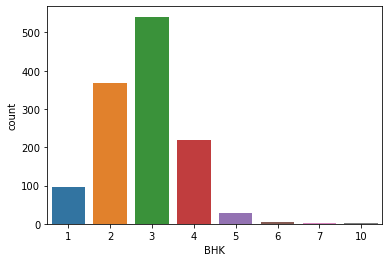

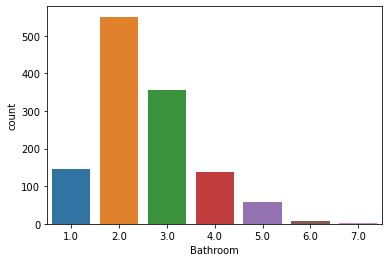

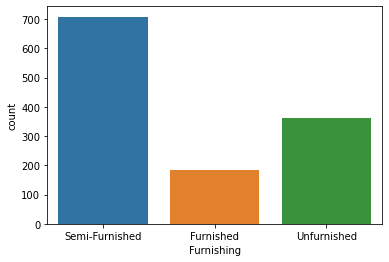

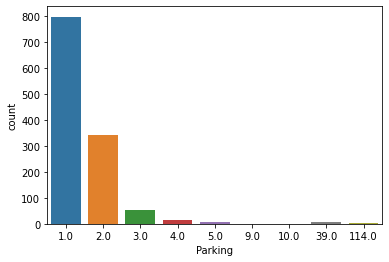

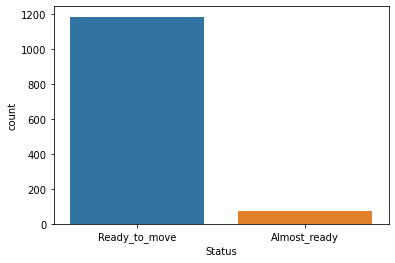

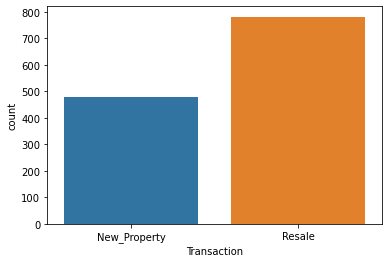

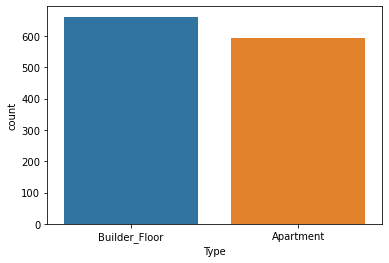

In [10]:
#'BHK', 'Bathroom', 'Furnishing', 'Parking','Status', 'Transaction', 'Type'
cp = df[['BHK', 'Bathroom', 'Furnishing', 'Parking','Status', 'Transaction', 'Type']]
for i in cp:
    fig, ax = plt.subplots(1,1)
    sns.countplot(cp[i])

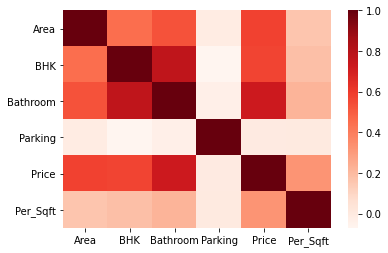

In [11]:
#correlation map
sns.heatmap(df.corr(), cmap="Reds")

 # STEP-3: Feature engineering

### 1) Missing value treatment

In [12]:
#Feature: Parking

before = df["Parking"].isnull().sum()
#df["Parking"].mode()
print("Mode for Parking: 1")
df["Parking"].fillna(1.0, inplace=True)
after = df["Parking"].isnull().sum()

print(f"No. of missing values before:{before}\nNo. of missing values after:{after}")

Mode for Parking: 1
No. of missing values before:33
No. of missing values after:0


In [13]:
#Feature: Bathroom

df.Bathroom.mode()
df["Bathroom"].fillna(2.0, inplace=True)

In [14]:
df["Per_Sqft"].median()

11291.5

In [15]:
df.columns

Index(['Area', 'BHK', 'Bathroom', 'Furnishing', 'Locality', 'Parking', 'Price',
       'Status', 'Transaction', 'Type', 'Per_Sqft'],
      dtype='object')

In [16]:
df[["Bathroom","Per_Sqft"]]

,Bathroom,Per_Sqft
0,2.0,NaN
1,2.0,6667.0
2,2.0,6667.0
3,2.0,6667.0
4,2.0,6667.0
...,...,...
1254,5.0,12916.0
1255,2.0,12916.0
1256,3.0,12916.0
1257,2.0,12916.0


In [17]:
#imputation

def impute_sqft(cols):
    sqft = cols[0]
    bath = cols[1]
    
    if pd.isnull(sqft):
        
        if bath==1:
            return 5000 
        elif bath==2:
            return 6667
        elif bath==3:
            return 6667
        elif bath==4:
            return 6154
        elif bath==5:
            return 12916
        elif bath==6:
            return 12916
        else:
            return 11292
    
    else:
        return sqft
    

df['Per_Sqft']=df[['Per_Sqft','Bathroom']].apply(impute_sqft,axis=1)


Text(50.0, 0.5, 'No. of missing values per feature ')

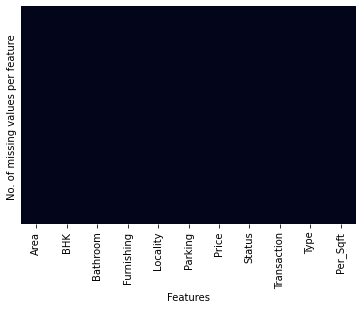

In [18]:
sns.heatmap(df.isnull(),cbar=False,yticklabels=False)
plt.xlabel("Features")
plt.ylabel("No. of missing values per feature ")

In [19]:
rows_with_nan = []
for index, row in df.iterrows():
    is_nan_series = row.isnull()
    if is_nan_series.any():
        rows_with_nan.append(index)

print(rows_with_nan)

[509, 510, 511, 512, 719]


In [20]:
df = df.drop([509, 510, 511, 512, 719])

Text(50.0, 0.5, 'No. of missing values per feature ')

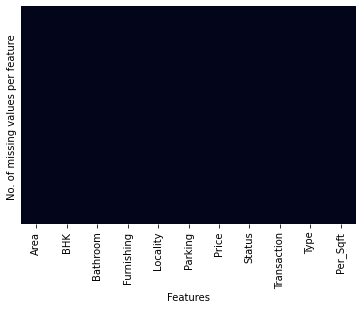

In [21]:
sns.heatmap(df.isnull(),cbar=False,yticklabels=False)
plt.xlabel("Features")
plt.ylabel("No. of missing values per feature ")

### 2) Outlier treatment

In [22]:
print("AREA","\nMin:",df["Area"].min(),"\nMax:",df["Area"].max(),)
print("\nPRICE","\nMin:",df["Price"].min(),"\nMax:",df["Price"].max())
print("\nSQFT","\nMin:",df["Per_Sqft"].min(),"\nMax:",df["Per_Sqft"].max())

AREA 
Min: 28.0 
Max: 24300.0

PRICE 
Min: 1000000 
Max: 240000000

SQFT 
Min: 1259.0 
Max: 183333.0


Area is in SQFT 
The total Price & Price/sqft is in INR


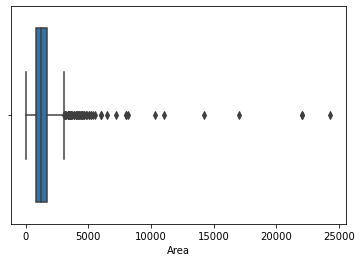

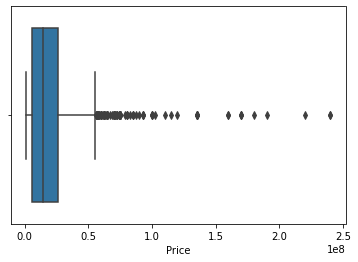

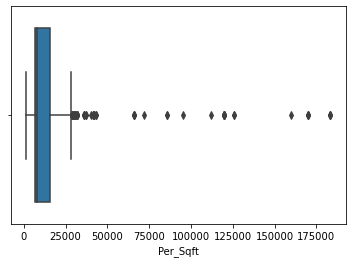

In [23]:
bp = df[["Area","Price","Per_Sqft"]]
print("Area is in SQFT","\nThe total Price & Price/sqft is in INR")
for x in bp:
    fig, ax = plt.subplots(1,1)
    sns.boxplot(bp[x])

#### Normalizing using IQR (bound method)

In [24]:
df = df[(df['BHK']<7)&(df['Bathroom']<6)&(df['Parking']<9)&(df['Area']<10000)]
print('New dataset shape:',df.shape)

New dataset shape: (1224, 11)


Area is in SQFT 
The total Price & Price/sqft is in INR


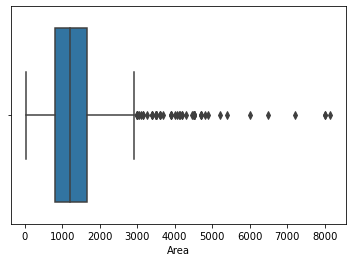

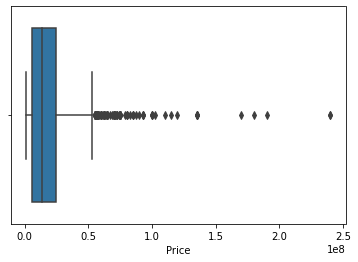

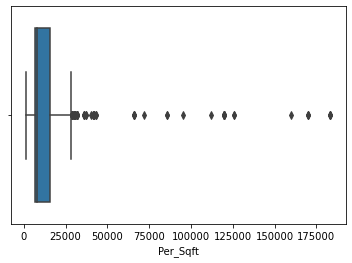

In [25]:
bp = df[["Area","Price","Per_Sqft"]]
print("Area is in SQFT","\nThe total Price & Price/sqft is in INR")
for x in bp:
    fig, ax = plt.subplots(1,1)
    sns.boxplot(bp[x])

In [26]:
df=df.drop_duplicates()

### 3) Feature generation/ Encoding

In [27]:
df = df.drop(["Locality"],axis=1)

In [28]:
df.head()

,Area,BHK,Bathroom,Furnishing,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,6667.0
1,750.0,2,2.0,Semi-Furnished,1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0


In [29]:
df.columns

Index(['Area', 'BHK', 'Bathroom', 'Furnishing', 'Parking', 'Price', 'Status',
       'Transaction', 'Type', 'Per_Sqft'],
      dtype='object')

In [30]:
#len(df.columns) = 10
non_dummy_cols = ['Area', 'BHK', 'Bathroom', 'Parking', 'Price', 'Per_Sqft'] 
# Takes all the other columns
dummy_cols = list(set(df.columns) - set(non_dummy_cols))
df = pd.get_dummies(df, columns=dummy_cols, drop_first=True)

In [31]:
df.head()

,Area,BHK,Bathroom,Parking,Price,Per_Sqft,Transaction_Resale,Type_Builder_Floor,Status_Ready_to_move,Furnishing_Semi-Furnished,Furnishing_Unfurnished
0,800.0,3,2.0,1.0,6500000,6667.0,0,1,1,1,0
1,750.0,2,2.0,1.0,5000000,6667.0,0,0,1,1,0
2,950.0,2,2.0,1.0,15500000,6667.0,1,0,1,0,0
3,600.0,2,2.0,1.0,4200000,6667.0,1,1,1,1,0
4,650.0,2,2.0,1.0,6200000,6667.0,0,1,1,1,0


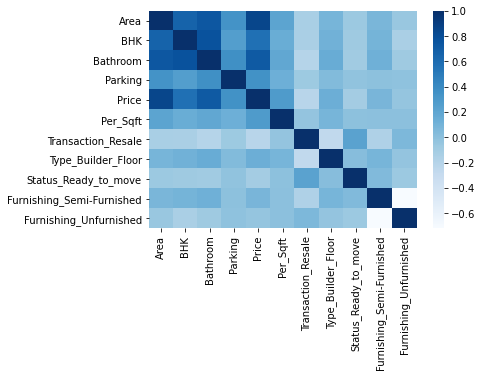

In [32]:
sns.heatmap(df.corr(),cmap="Blues")

# STEP-4: Hypothesis formulation

## Hypothesis-1 (Chi square test):
### H0: The no. of bathrooms and bedrooms are independent.
### H1: The no. of bathrooms and bedrooms are dependent.

In [33]:
pd.crosstab(df["Bathroom"],df["BHK"])

BHK,1,2,3,4,5,6
Bathroom,,,,,,
1.0,75,53,5,3,0,0
2.0,12,272,204,15,1,0
3.0,0,12,265,43,1,2
4.0,0,1,20,100,3,2
5.0,0,0,0,43,10,1


In [34]:
from scipy.stats import chi2_contingency

In [35]:
bath_bhk = [[75,53,5,3,0,0],
            [12,272,204,15,1,0],
            [0,12,265,43,1,2],
            [0,1,20,100,3,2],
            [0,0,0,43,10,1]] 
stat, p, dof, expected = chi2_contingency(bath_bhk) 
alpha = 0.05
print("p-value:" + str(p)) 
if p <= alpha: 
    print("We reject H0; The no. of bathrooms and bedrooms are dependent") 
else: 
    print("We accept H0; The no. of bathrooms and bedrooms are independent")

p-value:1.579993998549437e-307
We reject H0; The no. of bathrooms and bedrooms are dependent


## Hypothesis-2 (_t_-test):
### H0: Area does not influence/impact Price of the house.
### H1: Area influences/impacts Price of the house.

Text(0.5, 6.79999999999999, 'Price in INR')

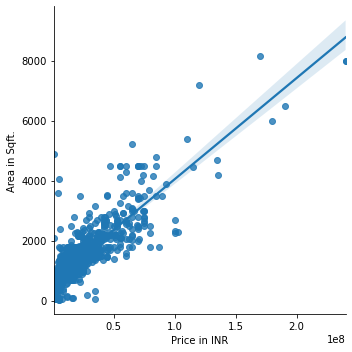

In [36]:
sns.lmplot(data=df,x="Price",y="Area")
plt.ylabel("Area in Sqft.")
plt.xlabel("Price in INR")

In [37]:
from scipy import stats
df[["Area","Price"]].describe()
ttest,pval = stats.ttest_rel(df["Area"], df["Price"])
print("p-value:",pval)
if pval<0.05:
    print("We reject H0; Area influences/impacts Price of the house.")
else:
    print("We accept H0; Area does not influence/impact Price of the house.")

p-value: 2.583460881678785e-143
We reject H0; Area influences/impacts Price of the house.


# STEP-5: Feature selection

In [38]:
df.columns

Index(['Area', 'BHK', 'Bathroom', 'Parking', 'Price', 'Per_Sqft',
       'Transaction_Resale', 'Type_Builder_Floor', 'Status_Ready_to_move',
       'Furnishing_Semi-Furnished', 'Furnishing_Unfurnished'],
      dtype='object')

In [39]:
predictors = df[['Area', 'BHK', 'Bathroom', 'Parking','Per_Sqft',
       'Status_Ready_to_move', 'Transaction_Resale', 'Type_Builder_Floor',
       'Furnishing_Semi-Furnished', 'Furnishing_Unfurnished']]
target = df["Price"]

### Using Chi square and Select k best for selection of features

In [40]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

In [41]:
best_ft = SelectKBest(score_func = chi2, k = 5)
fit = best_ft.fit(predictors,target)

In [42]:
feat = pd.DataFrame(fit.scores_)
score = pd.DataFrame(predictors.columns)
new_df = pd.concat([score,feat], axis = 1)
new_df.columns = ['FEATURES','SCORE']
b_5 = new_df.nlargest(5,'SCORE')

In [43]:
b_5

,FEATURES,SCORE
4,Per_Sqft,9.659747e+06
0,Area,5.998459e+05
2,Bathroom,3.423358e+02
1,BHK,2.248332e+02
9,Furnishing_Unfurnished,2.183310e+02


# STEP-6: Prediction

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
b_5["FEATURES"]

4                  Per_Sqft
0                      Area
2                  Bathroom
1                       BHK
9    Furnishing_Unfurnished
Name: FEATURES, dtype: object

In [46]:
X = df[["Per_Sqft","Area","Bathroom","BHK","Furnishing_Unfurnished"]]
y = df["Price"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=1/3,random_state=0)

In [47]:
from sklearn.linear_model import LinearRegression

In [48]:
lm = LinearRegression()
lm.fit(X_train,y_train)

LinearRegression()

In [49]:
print("Intercept:",lm.intercept_)
print("Coefficient:",lm.coef_)
cdf = pd.DataFrame(lm.coef_, X.columns, columns = ['Coefficient'])
cdf


Intercept: -12695168.63123114
Coefficient: [ 1.27144752e+02  1.85069353e+04  6.84110741e+06 -3.97523593e+06
 -1.21585053e+05]


,Coefficient
Per_Sqft,1.271448e+02
Area,1.850694e+04
Bathroom,6.841107e+06
BHK,-3.975236e+06
Furnishing_Unfurnished,-1.215851e+05


In [50]:
y_hat = lm.predict(X_test)

In [51]:
act_pred = pd.DataFrame({'Actual': y_test, 'Predicted': y_hat})
act_pred.head()

,Actual,Predicted
1027,17000000,1.312948e+07
147,11000000,1.046124e+07
1014,7000000,1.308649e+07
691,21000000,2.173448e+07
129,22000000,2.323988e+07


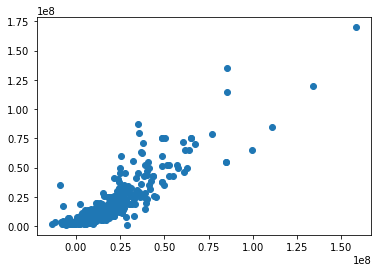

In [52]:
plt.scatter(y_hat,y_test)

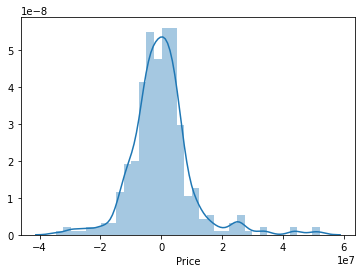

In [53]:
sns.distplot(y_test-y_hat)

In [54]:
from sklearn import metrics  
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_hat))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_hat))
print('R2 Score:', round(metrics.r2_score(y_test, y_hat)*100),"%")

Mean Absolute Error: 6911639.266079372
Mean Squared Error: 105415352101438.95
R2 Score: 77.0 %
